# ML Lab 2 — Data Cleaning & Exploratory Data Analysis
## Telco Customer Churn
 
**Name:** Abdul Qudoos
**CMS:** 023-24-0233

github repo link: https://github.com/abdulqudoos181005/ML_leaning_journey

> This notebook follows the 12 parts and 26 tasks in the provided lab manual.  
> Put the Telco Customer Churn CSV in the same folder as this notebook before running it.


## Part 1 — The Business Problem

### Task 1
In 2–3 sentences, describe the business problem in your own words and identify the likely target variable.

**Answer:**  
The telecommunications company wants to understand which customers are likely to leave so that it can take action before they churn. Each row represents a customer and the likely target variable is `Churn`, which tells whether the customer left the company.

### Task 2
List 5 useful predictors and 2 columns that are expected to be useless as predictors. Justify each choice.

| Column | Expected usefulness | Reason |
|---|---|---|
| `tenure` | Useful | Length of the customer's relationship may be related to churn. |
| `Contract` | Useful | Contract type can affect a customer's likelihood of leaving. |
| `MonthlyCharges` | Useful | Monthly cost may influence churn behavior. |
| `InternetService` | Useful | Different service types may have different churn patterns. |
| `PaymentMethod` | Useful | Payment method can be associated with customer behavior. |
| `customerID` | Useless | It is an identifier, not a meaningful customer characteristic. |
| `Churn` | Not a predictor | It is the target that we want to predict. |

### Task 3
Write 2 questions you personally want the dataset to answer.

1. Does contract type have a strong relationship with customer churn?
2. Are customers with higher monthly charges more likely to churn?

## Setup and Dataset Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# Change this filename if your CSV has a different name.
file_name = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_name)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Part 2 — Exploring the Dataset Structure

### Task 4
Find the number of customers and features and separate numerical and categorical features.

In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

numeric_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(exclude=np.number).columns.tolist()

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Numerical features:
['SeniorCiti

### Task 5
Identify identifier columns and columns whose data type looks wrong.

In [3]:
print("Potential identifier columns:")
print([c for c in df.columns if "id" in c.lower()])

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

Potential identifier columns:
['customerID']

Data types:


,dtype
customerID,str
gender,str
SeniorCitizen,int64
Partner,str
Dependents,str
tenure,int64
PhoneService,str
MultipleLines,str
InternetService,str
OnlineSecurity,str


**Interpretation:** `customerID` is an identifier rather than a predictive feature. `TotalCharges` is worth checking because it represents a monetary quantity but may initially be stored as text in some versions of the dataset.

### Task 6
Choose 3 categorical columns and inspect their unique values.

In [4]:
check_cols = ["gender", "Contract", "PaymentMethod"]

for col in check_cols:
    print(f"--- {col} ---")
    print(df[col].unique())
    print()

--- gender ---
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

--- Contract ---
<ArrowStringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

--- PaymentMethod ---
<ArrowStringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str



## Part 3 — Investigating Data Quality

### Task 7
Report missing values as counts and percentages.

In [5]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent
}).sort_values("Missing Count", ascending=False)

display(missing_report)

,Missing Count,Missing Percentage
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


**Decision:** Missing values in a meaningful feature require investigation before modeling. Columns with no missing values require no missing-value treatment. The exact cleaning decision should be based on the output above rather than assuming a fixed method.

### Task 8
Check duplicate rows and duplicate customer IDs separately.

In [6]:
print("Duplicate rows:", df.duplicated().sum())

if "customerID" in df.columns:
    print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


**Interpretation:** Duplicate rows and duplicate IDs are different checks. Two different rows can have the same customer ID even when the complete rows are not identical.

### Task 9
Search for suspicious, invalid, or inconsistently formatted values.

In [7]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(20))


--- customerID ---
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
9305-CDSKC    1
1452-KIOVK    1
6713-OKOMC    1
7892-POOKP    1
6388-TABGU    1
9763-GRSKD    1
7469-LKBCI    1
8091-TTVAX    1
0280-XJGEX    1
5129-JLPIS    1
3655-SNQYZ    1
8191-XWSZG    1
9959-WOFKT    1
4190-MFLUW    1
4183-MYFRB    1
Name: count, dtype: int64

--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity

C:\Users\Microsoft\AppData\Local\Temp\ipykernel_3480\1920103901.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [8]:
# Check numeric-looking columns for conversion problems
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    if col in df.columns:
        converted = pd.to_numeric(df[col], errors="coerce")
        print(col, "values becoming NaN after numeric conversion:",
              converted.isna().sum())

tenure values becoming NaN after numeric conversion: 0
MonthlyCharges values becoming NaN after numeric conversion: 0
TotalCharges values becoming NaN after numeric conversion: 11


## Part 4 — Data Cleaning Decisions

### Task 10 — Cleaning Decision Table

Fill this table after inspecting the actual outputs above.

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| `TotalCharges` stored as text | Convert to numeric | `pd.to_numeric(..., errors="coerce")` | It represents a numeric billing amount. |
| Missing values | Investigate and handle | `fillna()` or `dropna()` | Choice depends on the amount and meaning of missing data. |
| Duplicate rows | Remove if confirmed duplicates | `drop_duplicates()` | Exact duplicate records should not be counted twice. |
| Duplicate customer IDs | Investigate before removal | Group/count by ID | Repeated IDs are not automatically identical rows. |
| Unwanted identifier | Remove from ML features | `drop()` | An identifier does not describe customer behavior. |

In [9]:
# Work on a copy so the original raw dataframe remains available.
clean_df = df.copy()

# Convert TotalCharges when it exists.
if "TotalCharges" in clean_df.columns:
    clean_df["TotalCharges"] = pd.to_numeric(
        clean_df["TotalCharges"], errors="coerce"
    )

# Remove exact duplicate rows.
clean_df = clean_df.drop_duplicates().copy()

# Remove identifier column when justified.
if "customerID" in clean_df.columns:
    clean_df = clean_df.drop(columns=["customerID"])

# Handle missing values in numeric columns using the median.
# This is transparent and avoids losing rows unnecessarily.
numeric_cols = clean_df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    if clean_df[col].isnull().any():
        clean_df[col] = clean_df[col].fillna(clean_df[col].median())

# Handle missing categorical values using the mode.
categorical_cols = clean_df.select_dtypes(exclude=np.number).columns
for col in categorical_cols:
    if clean_df[col].isnull().any():
        mode_value = clean_df[col].mode()
        if len(mode_value) > 0:
            clean_df[col] = clean_df[col].fillna(mode_value.iloc[0])

print("Cleaned shape:", clean_df.shape)
print("\nRemaining missing values:")
display(clean_df.isnull().sum())

Cleaned shape: (7043, 20)

Remaining missing values:


gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Task 11
Confirm that the cleaning decisions resolved the identified issues.

In [10]:
print("Remaining duplicate rows:", clean_df.duplicated().sum())
print("\nRemaining missing values:")
display(clean_df.isnull().sum())

print("\nData types:")
display(clean_df.dtypes)

Remaining duplicate rows: 22

Remaining missing values:


gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Data types:


gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

## Part 5 — Univariate EDA

### Task 12
Visualize at least 2 numerical and 2 categorical features. Write an interpretation after each chart.

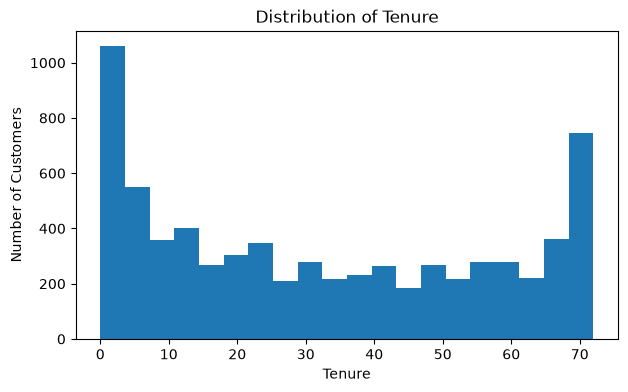

In [11]:
# Numerical feature 1
plt.figure(figsize=(7, 4))
clean_df["tenure"].plot(kind="hist", bins=20)
plt.title("Distribution of Tenure")
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")
plt.show()

**Interpretation:** The histogram shows how customers are distributed across different tenure values. Inspect whether the distribution is concentrated among newer customers or spread across the customer lifetime.

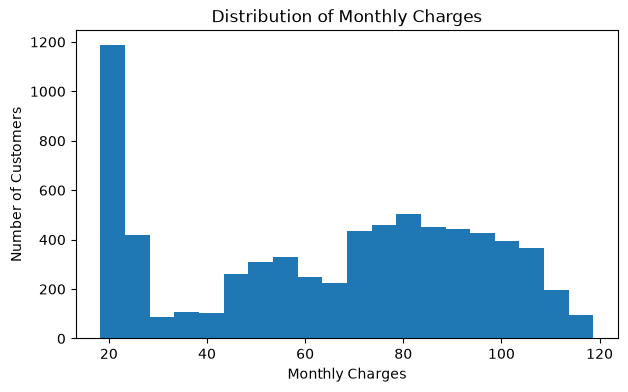

In [12]:
# Numerical feature 2
plt.figure(figsize=(7, 4))
clean_df["MonthlyCharges"].plot(kind="hist", bins=20)
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

**Interpretation:** This chart shows the range and concentration of monthly charges. A long tail would indicate skewness and could point to a smaller group of customers with unusually high charges.

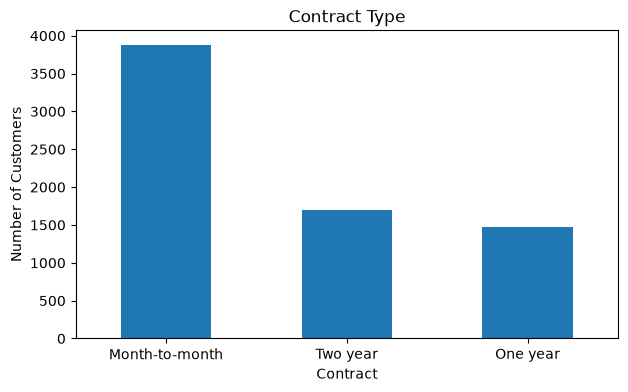

In [13]:
# Categorical feature 1
plt.figure(figsize=(7, 4))
clean_df["Contract"].value_counts().plot(kind="bar")
plt.title("Contract Type")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

**Interpretation:** The bars show how common each contract type is in the dataset. This helps identify whether the dataset is dominated by one contract category.

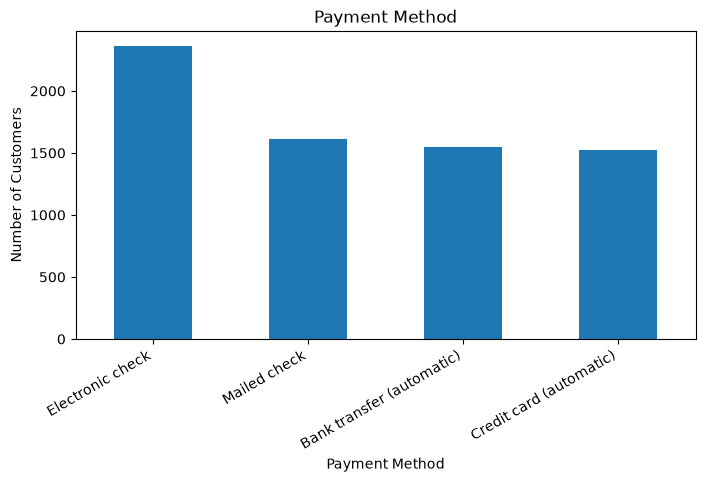

In [14]:
# Categorical feature 2
plt.figure(figsize=(8, 4))
clean_df["PaymentMethod"].value_counts().plot(kind="bar")
plt.title("Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30, ha="right")
plt.show()

**Interpretation:** The chart compares the number of customers using each payment method. Large differences in category size should be considered when interpreting later churn-rate comparisons.

### Task 13
Check numerical features for outliers and skewness.


tenure
Skewness: 0.24


,tenure
count,7043.000000
mean,32.371149
std,24.559481
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


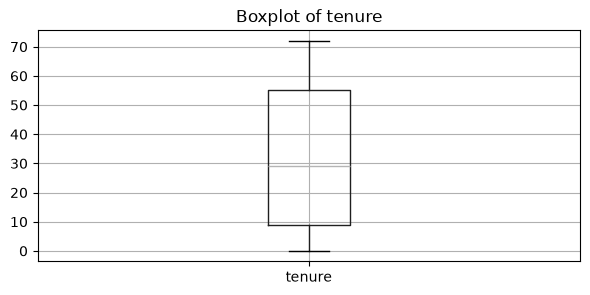


MonthlyCharges
Skewness: -0.221


,MonthlyCharges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


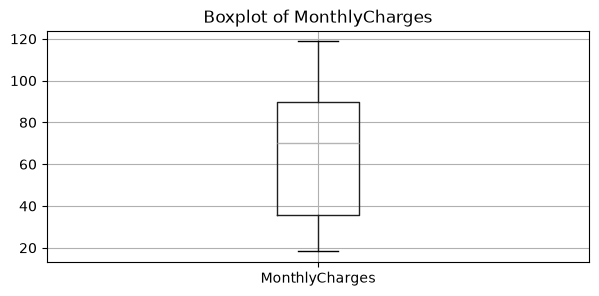


TotalCharges
Skewness: 0.964


,TotalCharges
count,7043.000000
mean,2281.916928
std,2265.270398
min,18.800000
25%,402.225000
50%,1397.475000
75%,3786.600000
max,8684.800000


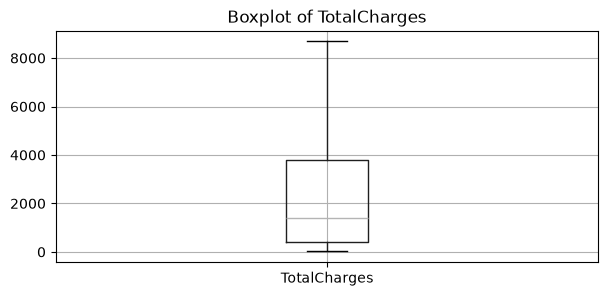

In [15]:
num_for_check = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in num_for_check:
    if col in clean_df.columns:
        print(f"\n{col}")
        print("Skewness:", round(clean_df[col].skew(), 3))
        display(clean_df[[col]].describe())

        plt.figure(figsize=(7, 3))
        clean_df.boxplot(column=col)
        plt.title(f"Boxplot of {col}")
        plt.show()

## Part 6 — Target Variable Analysis

### Task 14
Report churn counts and percentages and decide whether the target is balanced.

In [16]:
churn_counts = clean_df["Churn"].value_counts()
churn_percent = clean_df["Churn"].value_counts(normalize=True).mul(100).round(2)

churn_report = pd.DataFrame({
    "Count": churn_counts,
    "Percentage": churn_percent
})

display(churn_report)

,Count,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


**Interpretation:** Compare the two class percentages. If one class is substantially larger than the other, the target is imbalanced.

### Task 15
Explain why class imbalance matters for later classification.

**Answer:** Class imbalance can make overall accuracy misleading because a model may perform well on the majority class while performing poorly on the minority class. Therefore, the distribution of the target affects how model performance should be interpreted.

## Part 7 — Bivariate Analysis: Features vs. Churn

### Task 16
Investigate at least 2 categorical features against Churn using Observation / Evidence / Possible Explanation.

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


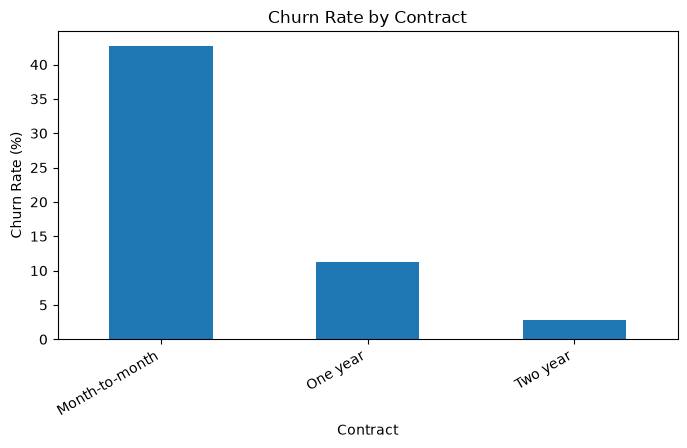

In [17]:
rate = pd.crosstab(
    clean_df["Contract"],
    clean_df["Churn"],
    normalize="index"
) * 100

display(rate)

rate["Yes"].plot(kind="bar", figsize=(8, 4))
plt.title("Churn Rate by Contract")
plt.xlabel("Contract")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

**Observation:** Compare the churn percentages across `Contract` categories.  
**Evidence:** Use the displayed churn-rate table and chart.  
**Possible Explanation:** Differences may reflect differences in customer commitment, service experience, pricing, or customer characteristics. The pattern is an association, not proof of causation.

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


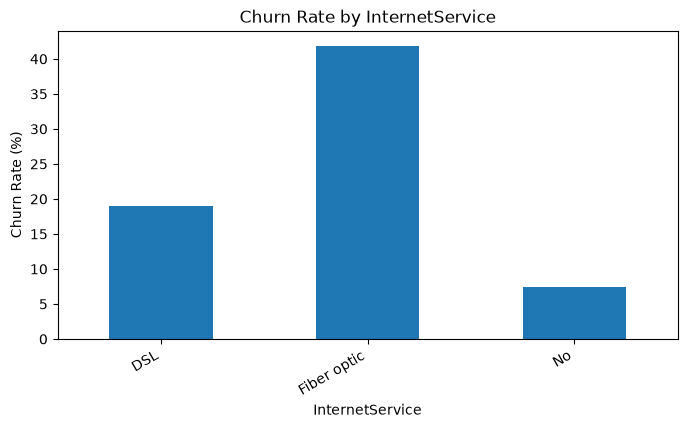

In [18]:
rate = pd.crosstab(
    clean_df["InternetService"],
    clean_df["Churn"],
    normalize="index"
) * 100

display(rate)

rate["Yes"].plot(kind="bar", figsize=(8, 4))
plt.title("Churn Rate by InternetService")
plt.xlabel("InternetService")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

**Observation:** Compare the churn percentages across `InternetService` categories.  
**Evidence:** Use the displayed churn-rate table and chart.  
**Possible Explanation:** Differences may reflect differences in customer commitment, service experience, pricing, or customer characteristics. The pattern is an association, not proof of causation.

### Task 17
Investigate at least 2 numerical features against Churn.

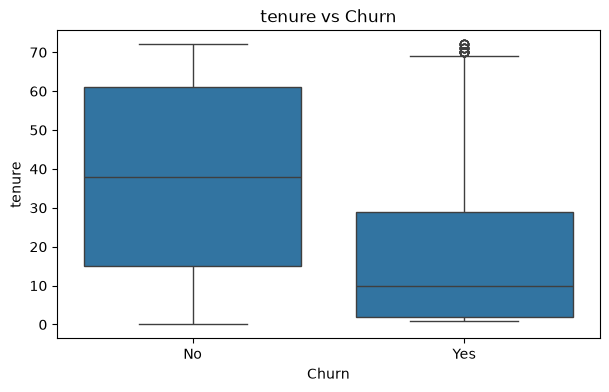

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [19]:
plt.figure(figsize=(7, 4))
sns.boxplot(x="Churn", y="tenure", data=clean_df)
plt.title("tenure vs Churn")
plt.show()

display(clean_df.groupby("Churn")["tenure"].describe())

**Observation:** Compare the distributions of `tenure` between customers who churned and those who did not.  
**Evidence:** Use the boxplot and group statistics above.  
**Possible Explanation:** Differences may indicate that `tenure` is associated with churn behavior, although the analysis does not establish causation.

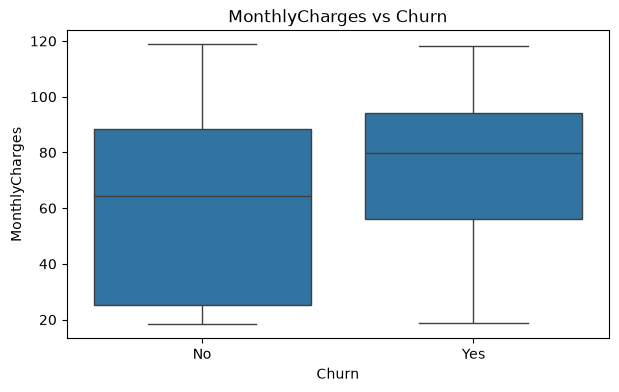

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


In [20]:
plt.figure(figsize=(7, 4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=clean_df)
plt.title("MonthlyCharges vs Churn")
plt.show()

display(clean_df.groupby("Churn")["MonthlyCharges"].describe())

**Observation:** Compare the distributions of `MonthlyCharges` between customers who churned and those who did not.  
**Evidence:** Use the boxplot and group statistics above.  
**Possible Explanation:** Differences may indicate that `MonthlyCharges` is associated with churn behavior, although the analysis does not establish causation.

## Part 8 — Correlation & Feature Relationships

### Task 18
Compute and visualize the numerical correlation matrix.

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102652
tenure,0.016567,1.000000,0.247900,0.825464
MonthlyCharges,0.220173,0.247900,1.000000,0.650864
TotalCharges,0.102652,0.825464,0.650864,1.000000


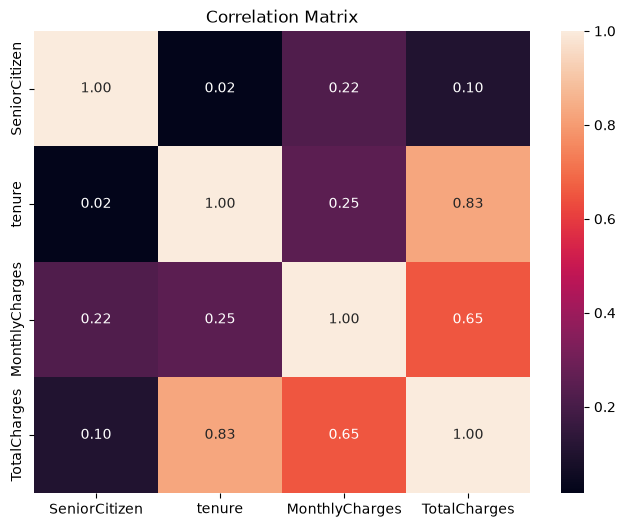

In [21]:
corr_matrix = clean_df.corr(numeric_only=True)

display(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

**Interpretation:** Identify the pair or pairs with the largest absolute correlation values. Strong correlation means the variables move together statistically; it does not by itself explain why they are related.

### Task 19
Does correlation imply causation? Could highly correlated features cause problems later?

**Answer:** No. Correlation shows an association between variables but does not prove that one causes the other. Highly correlated features can provide redundant information and may complicate interpretation or feature selection in a future model.

## Part 9 — Data Leakage Awareness

### Task 20
Inspect columns for information that would only be available after churn or columns that are purely identifiers.

In [22]:
print("All columns:")
for col in df.columns:
    print("-", col)

print("\nPotential identifier columns:")
print([c for c in df.columns if "id" in c.lower()])

All columns:
- customerID
- gender
- SeniorCitizen
- Partner
- Dependents
- tenure
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaperlessBilling
- PaymentMethod
- MonthlyCharges
- TotalCharges
- Churn

Potential identifier columns:
['customerID']


**Suspect:** `customerID` is a pure identifier and should not be used as a predictive feature. The remaining columns should be reviewed according to whether their information would realistically be available at prediction time.

### Task 21
Explain what would happen if a leakage column were included.

**Answer:** A leakage column can give the model information that would not actually be available when making a real prediction. The model may therefore appear extremely accurate during evaluation but fail to perform realistically on future customers.

## Part 10 — ML-Readiness Checklist

### Task 22
Complete the ML-readiness table for every column.

In [23]:
rows = []

for col in df.columns:
    dtype = str(df[col].dtype)

    if col.lower() == "customerid":
        role = "Identifier"
        action = "Remove"
        reason = "Identifier; not a meaningful customer feature."
    elif col == "Churn":
        role = "Target"
        action = "Keep"
        reason = "Target variable to predict."
    else:
        role = "Feature"
        action = "Clean / Keep"
        reason = "Potential predictor; inspect type and data quality."

    rows.append([col, dtype, role, action, reason])

readiness = pd.DataFrame(
    rows,
    columns=["Column", "Type", "Role", "Action", "Reason"]
)

display(readiness)

,Column,Type,Role,Action,Reason
0,customerID,str,Identifier,Remove,Identifier; not a meaningful customer feature.
1,gender,str,Feature,Clean / Keep,Potential predictor; inspect type and data qua...
2,SeniorCitizen,int64,Feature,Clean / Keep,Potential predictor; inspect type and data qua...
3,Partner,str,Feature,Clean / Keep,Potential predictor; inspect type and data qua...
4,Dependents,str,Feature,Clean / Keep,Potential predictor; inspect type and data qua...
5,tenure,int64,Feature,Clean / Keep,Potential predictor; inspect type and data qua...
6,PhoneService,str,Feature,Clean / Keep,Potential predictor; inspect type and data qua...
7,MultipleLines,str,Feature,Clean / Keep,Potential predictor; inspect type and data qua...
8,InternetService,str,Feature,Clean / Keep,Potential predictor; inspect type and data qua...
9,OnlineSecurity,str,Feature,Clean / Keep,Potential predictor; inspect type and data qua...


## Part 11 — Building the Clean Dataset

### Task 23
Produce `clean_df` and save it as `clean_churn.csv`. No train/test split, encoding, or model training is performed in this lab.

In [24]:
clean_df.to_csv("clean_churn.csv", index=False)

print("Saved clean_churn.csv")
print("Final shape:", clean_df.shape)

Saved clean_churn.csv
Final shape: (7043, 20)


### Task 24
Print the final dataframe information as evidence that the cleaning work is complete.

In [25]:
clean_df.info()

print("\nMissing values:")
display(clean_df.isnull().sum())

print("\nDuplicate rows:", clean_df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Duplicate rows: 22


## Part 12 — Key Findings & Final Reflection

### Task 25 — Five Key Findings

Use the actual outputs from this notebook to write five findings.

For each finding, use:

**Finding 1**  
- **Observation:**  
- **Evidence:**  
- **Interpretation:**  

**Finding 2**  
- **Observation:**  
- **Evidence:**  
- **Interpretation:**  

**Finding 3**  
- **Observation:**  
- **Evidence:**  
- **Interpretation:**  

**Finding 4**  
- **Observation:**  
- **Evidence:**  
- **Interpretation:**  

**Finding 5**  
- **Observation:**  
- **Evidence:**  
- **Interpretation:**  

### Task 26 — Final Reflection

1. **What was the most important data-quality issue you found?**  
   Write your answer from the actual investigation.

2. **What was the most interesting pattern you discovered?**  
   Refer to one of the EDA results.

3. **Which feature seems most useful for predicting churn?**  
   Give evidence from the analysis rather than simply guessing.

4. **Which feature should probably not be used, and why?**  
   Consider identifiers and possible leakage.

5. **What preprocessing will be required before ML modeling?**  
   Discuss conceptually; do not implement it here.

6. **What would you do next if you had another 3 hours?**  
   Describe the next useful investigation or preparation step.

## Bonus Tasks (Optional)

- Create one additional meaningful visualization.
- Investigate a surprising customer subgroup.
- Calculate churn rate across 2 or more customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in the dataset.

## Submission Checklist

- [ ] Notebook organized into Parts 1–12.
- [ ] All 26 tasks completed.
- [ ] Every major visualization has a written interpretation.
- [ ] ML-readiness table completed for every column.
- [ ] `clean_churn.csv` saved alongside the notebook.
- [ ] Notebook and cleaned dataset pushed to GitHub.
- [ ] No ML model trained in this lab.